# Reduce a whole raster: one point, a shard, or all of it

The batch half of `05_raster_lattice_single_point.ipynb`: run the SAME validated composition
(`midas_defect.raster.reduce_one_position`) over every point of a raster, assemble the results
into a table/map, and -- the point of this notebook -- check whether an apparent a/b splitting
survives a raster-wide honesty test before it gets quoted at all.

**Two ways to run it:**

- **Locally, from this notebook** (Steps 1-2 below): fine for a handful of points, or for the
  synthetic demo.
- **Sharded, from the command line**, for a real raster of hundreds of points: see
  `examples/raster_batch_cli.py` -- `--block-nr`/`--n-blocks` split the raster across processes,
  wired into whatever scheduler you have (or none). Step 4 shows the invocation.

No material default anywhere -- see `05_raster_lattice_single_point.ipynb`'s intro.


## Step 0 — CONFIG

With no `LOADER` set, this notebook runs on a synthetic raster with a KNOWN planted answer
(`midas_defect.synthetic.synthetic_dac_raster`) -- small, so the whole notebook executes in a
few minutes with no download.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tempfile

from midas_defect.geometry import Geometry
from midas_defect.raster import reduce_raster_block, assemble_raster_results

# ---- the only lines you change ------------------------------------------------------
A, C = 4.0, 10.0
SPACE_GROUP_NUMBER = 123
SIGMA_RTN = (0.02, 0.02, 0.02)
GEOM = None                 # a midas_defect.geometry.Geometry, or None for the synthetic fallback
LOADER = None                # LOADER(p) -> raw frame stack for point p, or None for the fallback
POINT_INDICES = None         # every point in the raster, or None for the synthetic fallback
N_BOOTSTRAP = 40             # kept small so the demo runs in minutes; use >= 300 for a real raster
# ---------------------------------------------------------------------------------------

if GEOM is None:
    GEOM = Geometry(lsd_um=120_000.0, bcy_px=384.0, bcz_px=384.0, px_um=172.0,
                    wavelength_A=0.4246, n_pix_y=768, n_pix_z=768,
                    omega_first_deg=-19.5, omega_step_deg=1.0, n_frames=40,
                    label="synthetic example")

N_POINTS = 6
if LOADER is None or POINT_INDICES is None:
    # synthetic_dac_raster plants one FIXED (a, b, c) for the whole raster; this demo wants a
    # REAL trend (b drifting across the raster, e.g. a pressure or composition gradient) for
    # Step 3 to have something to detect, so it calls synthetic_position_frames directly,
    # per point, instead.
    from scipy.spatial.transform import Rotation
    from midas_defect.synthetic import synthetic_position_frames

    def LOADER(p):
        U = Rotation.from_euler("zyx", [15.0 + 3 * p, 25.0, -8.0], degrees=True).as_matrix()
        b_p = 3.9 + 0.01 * p
        frames, truth = synthetic_position_frames(
            [U], a=A, b=b_p, c=C, space_group_number=SPACE_GROUP_NUMBER, geom=GEOM,
            hmax=8, kmax=8, lmax=14, seed=p)
        return frames
    POINT_INDICES = list(range(N_POINTS))
    print(f"No LOADER/POINT_INDICES set: using a synthetic {N_POINTS}-point raster with a "
         f"planted b drifting from {3.9:.3f} to {3.9 + 0.01 * (N_POINTS - 1):.3f}.")


No LOADER/POINT_INDICES set: using a synthetic 6-point raster with a planted b drifting from 3.900 to 3.950.


## Step 1 — Run the raster (locally, one shard = everything)

`reduce_raster_block` writes one `position_{p}.json` per point -- idempotent, so an interrupted
run can simply be resubmitted. For a real raster, run this from `examples/raster_batch_cli.py`
instead, sharded across `--n-blocks` processes (Step 4).


In [2]:
OUT_DIR = Path(tempfile.mkdtemp(prefix="raster_batch_demo_"))
done = reduce_raster_block(LOADER, GEOM, POINT_INDICES, OUT_DIR, block_nr=0, n_blocks=1,
                           a=A, c=C, space_group_number=SPACE_GROUP_NUMBER, sigma_rtn=SIGMA_RTN,
                           n_bootstrap=N_BOOTSTRAP)
print(f"wrote {len(done)} position file(s) to {OUT_DIR}")


wrote 6 position file(s) to /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/raster_batch_demo_3kawloxz


## Step 2 — Assemble into a table

A point a shard has not reached (or that raised) is `None`, not a zero -- keep it that way in
the table rather than filling it in, so a partial raster stays visibly partial.


 point  n_domains  quotable  delta_pct  sigma_pct          z
     0          1      True   2.610888   0.020521 127.227849
     1          1      True   2.316444   0.020343 113.867731
     2          1      True   2.048162   0.011980 170.963953
     3          1      True   1.811040   0.015913 113.811186
     4          1      True   1.563292   0.012950 120.713340
     5          1      True   1.286231   0.007049 182.477513


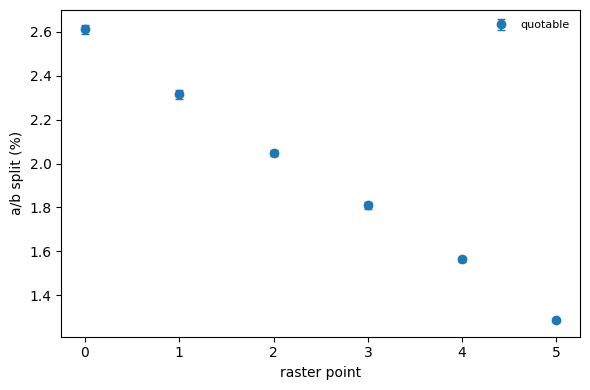

In [3]:
rows = assemble_raster_results(OUT_DIR, POINT_INDICES)
table = pd.DataFrame([
    dict(point=p,
        n_domains=len(r["domains"]) if r else None,
        quotable=r["quotable"] if r else None,
        delta_pct=r["split_pct"][0] if r and r["split_pct"] else None,
        sigma_pct=r["split_pct"][1] if r and r["split_pct"] else None,
        z=r["split_pct"][2] if r and r["split_pct"] else None)
    for p, r in zip(POINT_INDICES, rows)
])
print(table.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ok = table["quotable"] == True
ax.errorbar(table.loc[ok, "point"], table.loc[ok, "delta_pct"], yerr=table.loc[ok, "sigma_pct"],
           fmt="o", capsize=3, label="quotable")
if (~ok).any():
    ax.scatter(table.loc[~ok, "point"], table.loc[~ok, "delta_pct"], marker="x", color="0.5",
              label="not quotable")
ax.set_xlabel("raster point"); ax.set_ylabel("a/b split (%)"); ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()


## Step 3 — Raster-wide honesty: is this spread real?

The automated form of the project's own S5 lesson (`DIAGNOSIS.md` item 18, "delta spans zero"):
an apparent trend or spread across the raster can be indistinguishable from what IDENTICAL
crystals would give through the same real geometry and the same fit noise. Build a NULL raster
-- same cell and space group, one FIXED (a, b, c) at every point, independent noise only -- and
compare its point-to-point spread of `delta_pct` to the observed one. If they are comparable,
the observed variation is not established; only the OVERALL level (if every point agrees on the
sign, per `index_asymmetry`'s own warning) might still be worth reporting, and even that needs
the same scrutiny `05`'s Step 3 applied per position.

**Two ways this check itself can mislead you, found running it on real La3Ni2O7 2604 data
(2026-09-12; the finding and the two fixes below are both real, not hypothetical):**

1. **A degenerate null looks like a tight one.** `find_domains` can legitimately return NO
   domain at a synthetic null point too, and an earlier version of the cell below silently
   dropped those from `null_delta` -- on one real 5-position block, 3 of 5 null points
   returned zero domains, so a "0.0325%" null spread was actually the difference between 2
   near-duplicate orientations, not a distribution. The cell below now reports BOTH sides'
   surviving-point counts and refuses "supported" below `MIN_SURVIVORS` (4) on either side --
   read those counts before the spread numbers, every time.
2. **This whole check compares MAGNITUDE, not SIGN.** `delta_pct` is `abs(a-b)/mean` (unsigned).
   The artifact this check exists to catch (`index_asymmetry`'s own docstring,
   `manuals/solve-cell/ENVELOPE.md` #14) is diagnosed by a CONSISTENT SIGN across domains, not
   by how much the magnitude varies point to point -- a magnitude-spread test cannot tell "real
   crystal-to-crystal variation" apart from "the same known artifact expressing itself with
   different severity at each position," even with plenty of surviving points on both sides.
   Passing this check is necessary, not sufficient: also check whether `a > b` (or the
   equivalent) holds with the same sign at every position, and treat a POSITION-DEPENDENT
   domain count (like the real block above: 2/0/3/4/5 domains at 5 adjacent points) as reason
   to suspect the artifact before the physics.


In [4]:
def _null_loader(p, b_fixed=3.9):
    from scipy.spatial.transform import Rotation
    from midas_defect.synthetic import synthetic_position_frames
    U = Rotation.from_euler("zyx", [15.0 + 3 * p, 25.0, -8.0], degrees=True).as_matrix()
    frames, _truth = synthetic_position_frames(
        [U], a=A, b=b_fixed, c=C, space_group_number=SPACE_GROUP_NUMBER, geom=GEOM,
        hmax=8, kmax=8, lmax=14, seed=1000 + p)      # different noise, same everything else
    return frames

NULL_OUT = Path(tempfile.mkdtemp(prefix="raster_null_demo_"))
reduce_raster_block(_null_loader, GEOM, POINT_INDICES, NULL_OUT, a=A, c=C,
                    space_group_number=SPACE_GROUP_NUMBER, sigma_rtn=SIGMA_RTN,
                    n_bootstrap=N_BOOTSTRAP)
null_rows = assemble_raster_results(NULL_OUT, POINT_INDICES)
null_delta = np.array([r["split_pct"][0] for r in null_rows if r and r["split_pct"]])
obs_delta = table.loc[ok, "delta_pct"].to_numpy()

# MIN_SURVIVORS: /verify'd REFUTED on a real 5-position 2604 block (2026-09-12, claim
# a1c6f1f505cb, 4/4 lenses) -- `find_domains` can legitimately return zero domains at a
# synthetic null point too (not just real data), which used to be silently dropped here. On
# that block 3 of 5 null points returned no domain, so "null_spread" was the std of only 2
# points -- a near-duplicate pair, not a distribution -- while "obs_spread" stood on 3. The
# comparison read as "29x above the null" and was not: it was comparing a 3-point, noisy
# statistic against a 2-point, artificially tight one. Report the surviving counts always,
# and refuse the "supported" conclusion below a floor.
MIN_SURVIVORS = 4
print(f"surviving points: observed {len(obs_delta)}/{ok.sum()} quotable, "
     f"null {len(null_delta)}/{len(POINT_INDICES)}")
obs_spread = float(np.std(obs_delta)) if len(obs_delta) > 1 else float("nan")
null_spread = float(np.std(null_delta)) if len(null_delta) > 1 else float("nan")
print(f"observed point-to-point spread of delta: {obs_spread:.4f} %")
print(f"IDENTICAL-crystal null spread (noise only): {null_spread:.4f} %")
if len(obs_delta) < MIN_SURVIVORS or len(null_delta) < MIN_SURVIVORS:
    print(f"-> too few surviving points ({len(obs_delta)} observed, {len(null_delta)} null; "
         f"need >= {MIN_SURVIVORS} on EACH side) to trust this comparison at all -- a 2- or "
         "3-point std is not a distribution. Get more points before reading anything below "
         "this line as a verdict, not just a screen.")
elif np.isfinite(obs_spread) and np.isfinite(null_spread):
    if obs_spread > 2 * null_spread:
        print("-> the observed spread is well above the identical-crystal null: "
             "a real trend across the raster is supported.")
    else:
        print("-> the observed spread is NOT clearly distinguishable from the identical-crystal "
             "null: do not report a trend across this raster from this alone (the S5 lesson).")


surviving points: observed 6/6 quotable, null 6/6
observed point-to-point spread of delta: 0.4452 %
IDENTICAL-crystal null spread (noise only): 0.0153 %
-> the observed spread is well above the identical-crystal null: a real trend across the raster is supported.


## Step 4 — Scaling up: the CLI, sharded

For a real raster (hundreds of points), write a config module (see
`examples/raster_batch_cli.py`'s docstring) and run:

```
python raster_batch_cli.py --config my_raster.py --n-blocks 20 --block-nr $i --out-dir results/
```

once per shard `$i` in `0..19` -- one line per array-job task for whatever scheduler you have
(SLURM's `sbatch --array`, PBS, or a plain shell loop), or run them one after another on a
single machine. Every shard writes disjoint `position_{p}.json` files; `assemble_raster_results`
(Step 2) reads back however many of them exist, so a partially-finished raster is still usable.


## What this notebook does NOT do

- **No pooling across positions into one global cell.** Each position is refined against its
  OWN domain(s) only (see `05`'s closing notes). Jointly refining several POSITIONS' domains
  against one shared cell is a further, separate analysis your raster may or may not support --
  check the manufactured-null spread above first.
- **The null here is the simplest one** (fixed cell, independent Poisson noise). A real raster
  can also vary in illumination, sample motion, or a slowly drifting geometry -- none of that is
  in this null, so treat "distinguishable from this null" as necessary, not sufficient.
- **`quotable` per point still needs the honesty gates in `05`'s Step 3 to have passed.** This
  notebook's Step 3 adds a check ACROSS positions; it does not replace the per-position ones.
